In [1]:
import pandas as pd

In [2]:
urls_df = pd.read_parquet("/kaggle/input/urls-hm3/urls_hw3.parquet")

In [3]:
urls_df.local_picture.iloc[0]

'https://d.mradx.net/ecomimg/000/01/5e700ea85873.jpeg'

In [4]:
urls_df

,local_picture
0,https://d.mradx.net/ecomimg/000/01/5e700ea8587...
1,https://d.mradx.net/ecomimg/000/03/e2b43c661fa...
2,https://d.mradx.net/ecomimg/000/05/11fb0c2a50c...
3,https://d.mradx.net/ecomimg/000/06/1641c05b87e...
4,https://d.mradx.net/ecomimg/000/08/dbd24cd9b82...
...,...
2322410,https://d.mradx.net/ecomimg/fff/fc/13256a92698...
2322411,https://d.mradx.net/ecomimg/fff/fe/16bf5384941...
2322412,https://d.mradx.net/ecomimg/fff/fe/48f1c481a0b...
2322413,https://d.mradx.net/ecomimg/fff/ff/070b06d3ec5...


In [5]:
sampled_df = urls_df.sample(n=20000, random_state=42)

In [6]:
sampled_df

,local_picture
892755,https://d.mradx.net/ecomimg/c4c/6c/babc43c0a8d...
1813072,https://d.mradx.net/ecomimg/8f8/ed/7ff7f3d2fe6...
1204645,https://d.mradx.net/ecomimg/096/1a/3cfc43188c6...
757773,https://d.mradx.net/ecomimg/a70/cb/469e83a8c5f...
2245960,https://d.mradx.net/ecomimg/ef1/54/d56f7d074c7...
...,...
738476,https://d.mradx.net/ecomimg/a2c/a0/7e400e9764c...
2258670,https://d.mradx.net/ecomimg/f1e/62/1ab2acbce9c...
2259625,https://d.mradx.net/ecomimg/f21/c5/d7b16d2ac3a...
1795244,https://d.mradx.net/ecomimg/8ba/01/f0e1723529a...


In [7]:
import torch
import torchvision.models as models
from torchvision import transforms

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Загрузка модели ResNet (без головы)
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))  # Удаляем последний слой (классификатор)
model.to(device)
model.eval()

# Трансформации для изображения
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


In [9]:
import asyncio
import io

import aiohttp
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.asyncio import tqdm

In [10]:
def get_embedding(image):
    if image is None:
        return None
    try:
        image = transform(image).unsqueeze(0).to(device)  # Добавляем batch-размер и переносим на устройство
        with torch.no_grad():
            embedding = model(image)
        return embedding.squeeze().cpu().numpy().astype(np.float32)
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

In [11]:
async def download_image(session, url, timeout=10):
    try:
        async with session.get(url, timeout=timeout) as response:
            if response.status == 200:
                image_data = await response.read()
                return Image.open(io.BytesIO(image_data)).convert("RGB")
            return None
    except Exception as e:
        print(f"Error downloading {url}: {e}")
        return None

In [12]:
async def process_urls(df, batch_size=128):
    k = 0
    embeddings = []
    timeout = aiohttp.ClientTimeout(total=10)

    async with aiohttp.ClientSession(timeout=timeout) as session:
        for i in tqdm(range(0, len(df), batch_size), desc="Processing batches"):
            batch_urls = df["local_picture"].iloc[i:i+batch_size].tolist()
            tasks = [download_image(session, url) for url in batch_urls]
            images = await asyncio.gather(*tasks)

            batch_embeddings = [get_embedding(img) for img in images]
            embeddings.extend(batch_embeddings)
            k += len(batch_urls)

    df = df.copy()
    df["embeddings"] = embeddings
    return df

In [13]:
async def run_scrapper(df):
    result_df = await process_urls(df)
    print(result_df.head())
    return result_df

In [14]:
result_sampled_df = await run_scrapper(sampled_df)

Processing batches:  18%|█▊        | 28/157 [01:49<07:58,  3.71s/it]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Processing batches: 100%|██████████| 157/157 [10:15<00:00,  3.92s/it]

                                             local_picture  \
892755   https://d.mradx.net/ecomimg/c4c/6c/babc43c0a8d...   
1813072  https://d.mradx.net/ecomimg/8f8/ed/7ff7f3d2fe6...   
1204645  https://d.mradx.net/ecomimg/096/1a/3cfc43188c6...   
757773   https://d.mradx.net/ecomimg/a70/cb/469e83a8c5f...   
2245960  https://d.mradx.net/ecomimg/ef1/54/d56f7d074c7...   

                                                embeddings  
892755   [0.14560066, 1.5307571, 0.6331083, 0.06110397,...  
1813072  [1.1495204, 0.066942655, 0.0786376, 0.31762514...  
1204645  [0.31481773, 1.0047491, 0.8408634, 0.003243269...  
757773   [0.41766337, 0.17352538, 0.16247603, 0.5996374...  
2245960  [0.119820446, 0.7870787, 1.2241662, 0.0, 0.800...  


In [37]:
result_sampled_df

In [19]:
result_sampled_df = result_sampled_df.to_parquet("/kaggle/working/urls_hw3_emb.parquet")

In [38]:
result_sampled_df = pd.read_parquet("/kaggle/working/urls_hw3_emb.parquet")

In [25]:
some_url = urls_df["local_picture"].iloc[1784539]
some_url

'https://d.mradx.net/ecomimg/894/4a/3462705a246d.jpeg'

In [27]:
timeout = aiohttp.ClientTimeout(total=10)

async with aiohttp.ClientSession(timeout=timeout) as session:
    image_of_some_url = await download_image(session, some_url)

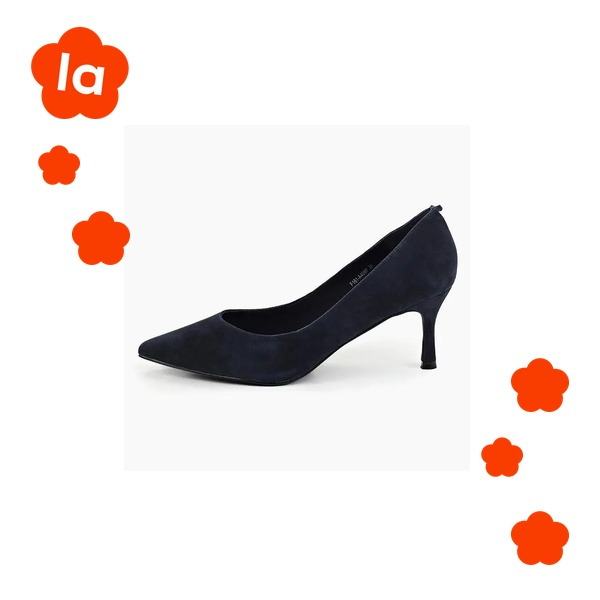

In [28]:
image_of_some_url

In [29]:
embedding_of_some_url = get_embedding(image_of_some_url)

In [30]:
embedding_of_some_url.shape

(2048,)

## Строим различные индексы

In [32]:
pip install faiss-cpu 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 61.2 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [33]:
import faiss

In [43]:
embeddings = np.vstack(result_sampled_df["embeddings"].values)

In [45]:
embeddings.shape

(20000, 2048)

### Flat Index

In [72]:
d = embeddings.shape[1]
np.random.seed(1234)  # для воспроизводимости

index_flat = faiss.IndexFlatL2(d)
print(index_flat.ntotal)
index_flat.add(embeddings)
print(index_flat.ntotal)

0
20000


### HNWS Index

In [ ]:
M = 32

index_hnsw = faiss.IndexHNSWFlat(
    d, M, faiss.METRIC_L2
)
index_hnsw.hnsw.efConstruction = 40
print(index_hnsw.ntotal)
index_hnsw.add(embeddings)
print(index_hnsw.ntotal)

0
20000


### IVF Index

In [74]:
nlist = 100
quantizer = faiss.IndexFlatL2(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
index_ivf.train(embeddings)
print(index_ivf.ntotal)
index_ivf.add(embeddings)
print(index_ivf.ntotal)

0
20000


In [75]:
import time


def measure_latency(index, query_vector, k=5):
    start_time = time.time()
    D, I = index.search(query_vector, k)
    return time.time() - start_time

In [ ]:
def search_in_index(index, query_vector, k=5):
    D, I = index.search(query_vector, k)
    return D, I

In [77]:
embedding_of_some_url

array([0.42029437, 0.9911047 , 0.6442003 , ..., 0.30701283, 2.016249  ,
       0.24959402], dtype=float32)

In [78]:
query = np.expand_dims(embedding_of_some_url, axis=0)
query

array([[0.42029437, 0.9911047 , 0.6442003 , ..., 0.30701283, 2.016249  ,
        0.24959402]], dtype=float32)

In [84]:
latency_results = {
    "FlatIndex": measure_latency(index_flat, query),
    "HNSWIndex": measure_latency(index_hnsw, query),
    "IVFFlat": measure_latency(index_ivf, query),
}

print(latency_results)

{'FlatIndex': 0.014885187149047852, 'HNSWIndex': 0.0003466606140136719, 'IVFFlat': 0.0005290508270263672}


Для одного элемента лучшие результаты показывает HNWS 

In [85]:
search_results = {
    "FlatIndex": search_in_index(index_flat, query),
    "HNSWIndex": search_in_index(index_hnsw, query),
    "IVFFlat": search_in_index(index_ivf, query),
}

for index_name in search_results:
    _, indexes = search_results[index_name]
    print(index_name, indexes)
    indexes = indexes[0]
    for index in indexes:
        url = result_sampled_df["local_picture"].iloc[index]
        print(index, url)
    print("\n\n")

FlatIndex [[10015 10369  1319 13534 14134]]
10015 https://d.mradx.net/ecomimg/063/4a/ba063f9c2d38.jpeg
10369 https://d.mradx.net/ecomimg/8cd/43/c7c423a87b2a.jpeg
1319 https://d.mradx.net/ecomimg/26b/e9/2a895b5ec26c.jpeg
13534 https://d.mradx.net/ecomimg/8c1/0e/a89230ec35b2.jpeg
14134 https://d.mradx.net/ecomimg/ba5/ba/93f7f1edd833.jpeg



HNSWIndex [[10015 10369  1319 13534 14134]]
10015 https://d.mradx.net/ecomimg/063/4a/ba063f9c2d38.jpeg
10369 https://d.mradx.net/ecomimg/8cd/43/c7c423a87b2a.jpeg
1319 https://d.mradx.net/ecomimg/26b/e9/2a895b5ec26c.jpeg
13534 https://d.mradx.net/ecomimg/8c1/0e/a89230ec35b2.jpeg
14134 https://d.mradx.net/ecomimg/ba5/ba/93f7f1edd833.jpeg



IVFFlat [[10369  1319 13534 14134 12082]]
10369 https://d.mradx.net/ecomimg/8cd/43/c7c423a87b2a.jpeg
1319 https://d.mradx.net/ecomimg/26b/e9/2a895b5ec26c.jpeg
13534 https://d.mradx.net/ecomimg/8c1/0e/a89230ec35b2.jpeg
14134 https://d.mradx.net/ecomimg/ba5/ba/93f7f1edd833.jpeg
12082 https://d.mradx.net/ecomimg/097/4b/

По качеству поиска практически одинаковые результаты

In [92]:
import matplotlib.pyplot as plt

In [93]:
latencys_hnsw = []
efs = [10, 50, 100, 200]
for ef in efs:
    index_hnsw.hnsw.efSearch = ef
    latencys_hnsw.append(measure_latency(index_hnsw, query))

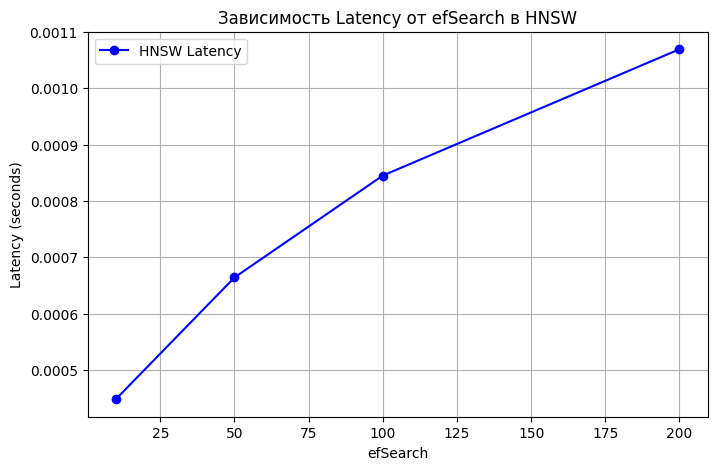

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(efs, latencys_hnsw, marker="o", linestyle="-", color="b", label="HNSW Latency")
plt.xlabel("efSearch")
plt.ylabel("Latency (seconds)")
plt.title("Зависимость Latency от efSearch в HNSW")
plt.legend()
plt.grid(True)
plt.show()

In [98]:
latencys_ivf = []
nprobes = [1, 5, 10, 20, 50 , 100]
for nprobe in nprobes:
    index_ivf.nprobe = nprobe
    latencys_ivf.append(measure_latency(index_ivf, query))

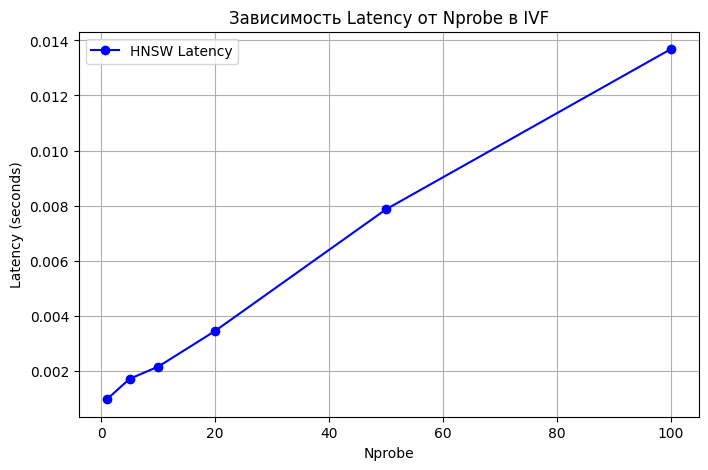

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(nprobes, latencys_ivf, marker="o", linestyle="-", color="b", label="HNSW Latency")
plt.xlabel("Nprobe")
plt.ylabel("Latency (seconds)")
plt.title("Зависимость Latency от Nprobe в IVF")
plt.legend()
plt.grid(True)
plt.show()